In [1]:
import cv2
print(cv2.__version__)

5.0.0


In [2]:
from pathlib import Path
import os
import random

import cv2
import yaml
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

plt.rcParams["figure.figsize"] = (8,6)

In [3]:
DATA_DIR = Path("../data/raw")

ADMS_PATH = DATA_DIR / "adms"
DROWSINESS_PATH = DATA_DIR / "drowsiness"
STATEFARM_PATH = DATA_DIR / "statefarm"

In [4]:
print(ADMS_PATH.exists())
print(DROWSINESS_PATH.exists())
print(STATEFARM_PATH.exists())

True
True
True


In [5]:
IMAGE_EXTENSIONS = [
    ".jpg",
    ".jpeg",
    ".png",
    ".bmp"
]
def count_images(folder):
    images = []
    for ext in IMAGE_EXTENSIONS:
        images.extend(folder.rglob(f"*{ext}"))
        images.extend(folder.rglob(f"*{ext.upper()}"))
    return images

In [6]:
adms_images = count_images(ADMS_PATH)
drowsiness_images = count_images(DROWSINESS_PATH)
statefarm_images = count_images(STATEFARM_PATH)

print(f"ADMS Images: {len(adms_images)}")
print(f"Drowsiness Images: {len(drowsiness_images)}")
print(f"StateFarm Images: {len(statefarm_images)}")

ADMS Images: 9884
Drowsiness Images: 4000
StateFarm Images: 22423


In [7]:
def show_random_image(image_list, title):

    img = cv2.imread(str(random.choice(image_list)))

    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    plt.figure(figsize=(6,6))

    plt.imshow(img)

    plt.title(title)

    plt.axis("off")

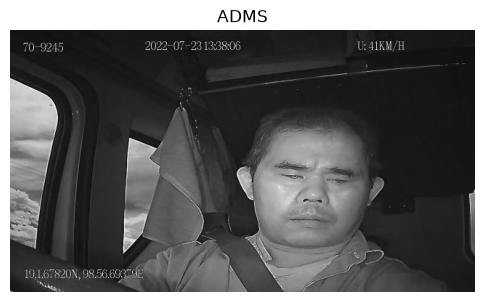

In [8]:
show_random_image(adms_images,"ADMS")

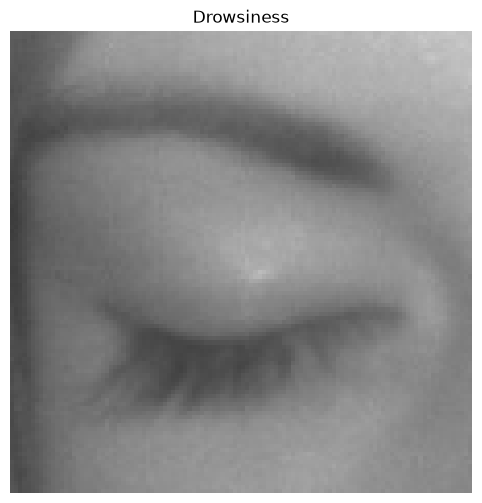

In [9]:
show_random_image(drowsiness_images,"Drowsiness")

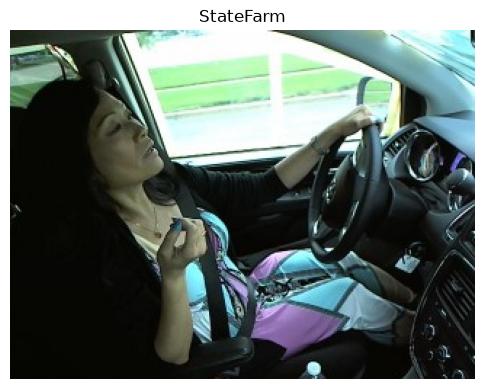

In [10]:
show_random_image(statefarm_images,"StateFarm")

In [11]:
yaml_path = ADMS_PATH / "data.yaml"

with open(yaml_path,"r") as f:

    data_yaml = yaml.safe_load(f)

data_yaml

{'train': '../train/images',
 'val': '../valid/images',
 'test': '../test/images',
 'nc': 5,
 'names': ['Open Eye', 'Closed Eye', 'Cigarette', 'Phone', 'Seatbelt']}

In [12]:
summary = pd.DataFrame({

    "Dataset":[
        "ADMS",
        "Drowsiness",
        "StateFarm"
    ],

    "Images":[
        len(adms_images),
        len(drowsiness_images),
        len(statefarm_images)
    ]
})

summary

,Dataset,Images
0,ADMS,9884
1,Drowsiness,4000
2,StateFarm,22423


In [13]:
from PIL import Image

def image_statistics(image_list, sample_size=500):

    widths = []
    heights = []

    sample = image_list[:min(sample_size, len(image_list))]

    for img_path in sample:

        try:

            img = Image.open(img_path)

            w, h = img.size

            widths.append(w)

            heights.append(h)

        except:

            continue

    return pd.DataFrame({

        "width": widths,

        "height": heights

    })

In [14]:
adms_stats = image_statistics(adms_images)

drowsiness_stats = image_statistics(drowsiness_images)

statefarm_stats = image_statistics(statefarm_images)

In [15]:
print("ADMS")

display(adms_stats.describe().T)

print()

print("Drowsiness")

display(drowsiness_stats.describe().T)

print()

print("StateFarm")

display(statefarm_stats.describe().T)

ADMS


,count,mean,std,min,25%,50%,75%,max
width,500.0,626.516,45.940296,360.0,640.0,640.0,640.0,640.0
height,500.0,456.736,103.369477,320.0,384.0,385.5,523.0,640.0



Drowsiness


,count,mean,std,min,25%,50%,75%,max
width,500.0,108.046,25.394836,65.0,89.0,98.0,129.0,170.0
height,500.0,108.046,25.394836,65.0,89.0,98.0,129.0,170.0



StateFarm


,count,mean,std,min,25%,50%,75%,max
width,500.0,320.0,0.0,320.0,320.0,320.0,320.0,320.0
height,500.0,240.0,0.0,240.0,240.0,240.0,240.0,240.0


Text(0, 0.5, 'Count')

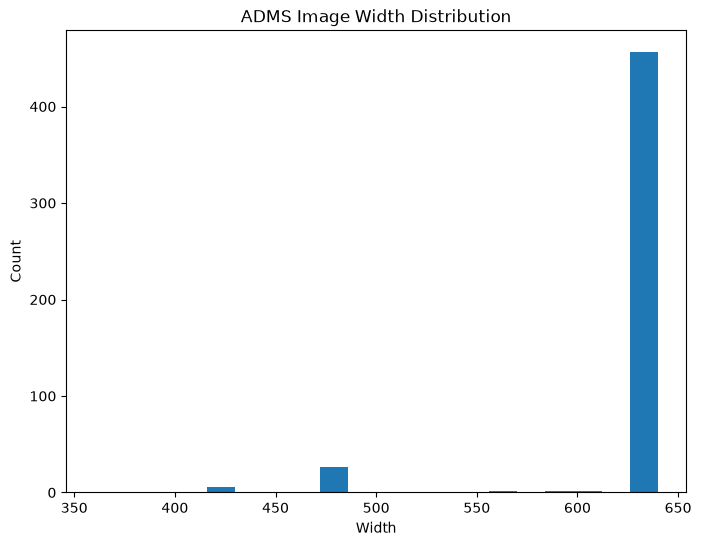

In [16]:
plt.hist(adms_stats["width"], bins=20)

plt.title("ADMS Image Width Distribution")

plt.xlabel("Width")

plt.ylabel("Count")

Text(0, 0.5, 'Count')

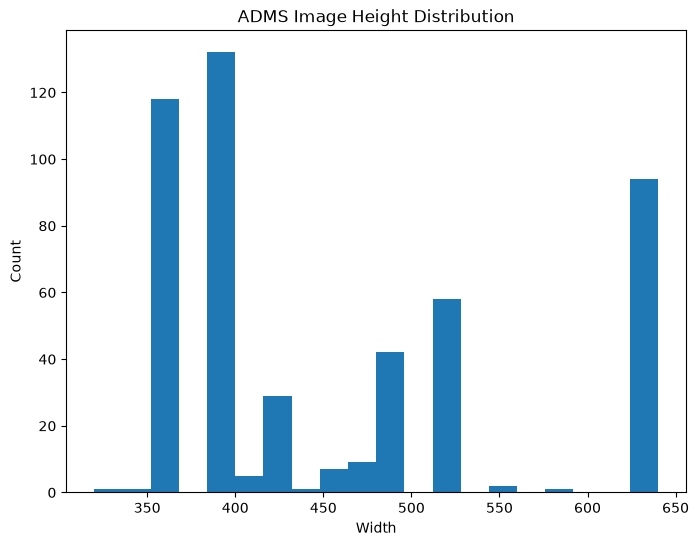

In [17]:
plt.hist(adms_stats["height"], bins=20)

plt.title("ADMS Image Height Distribution")

plt.xlabel("Width")

plt.ylabel("Count")

Text(0.5, 1.0, 'ADMS Image Resolution')

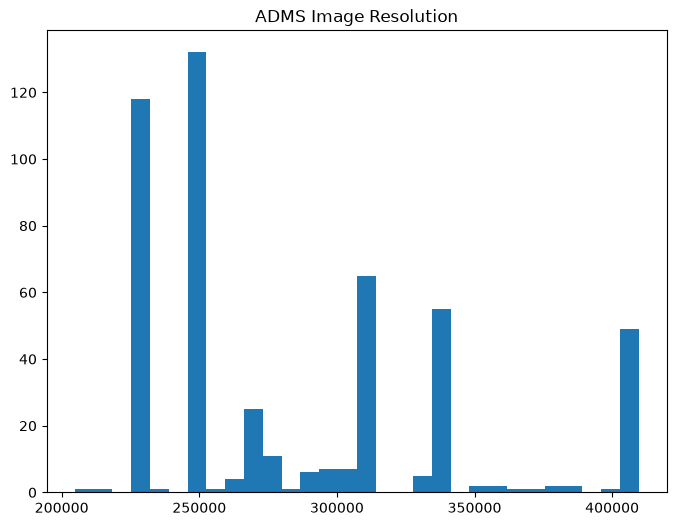

In [18]:
adms_stats["resolution"] = adms_stats["width"] * adms_stats["height"]

plt.hist(adms_stats["resolution"], bins=30)

plt.title("ADMS Image Resolution")

In [19]:
from collections import Counter

formats = Counter([img.suffix.lower() for img in adms_images])

formats

Counter({'.jpg': 9884})

In [20]:
from collections import Counter

formats = Counter([img.suffix.lower() for img in statefarm_images])

formats

Counter({'.jpg': 22423})

In [21]:
from collections import Counter

formats = Counter([img.suffix.lower() for img in drowsiness_images])

formats

Counter({'.png': 4000})

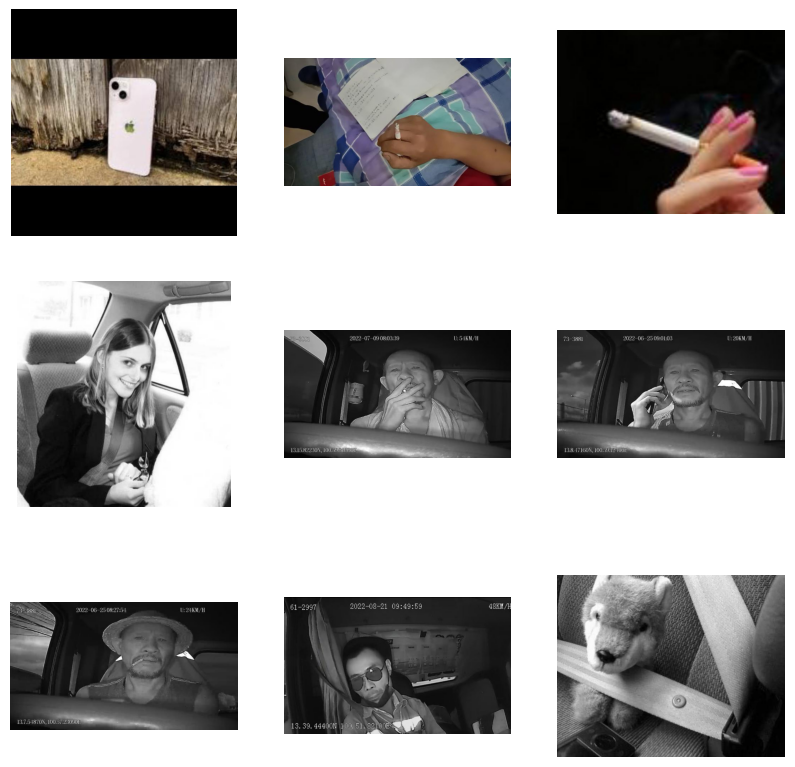

In [22]:
fig, axes = plt.subplots(3,3,figsize=(10,10))

for ax in axes.flat:

    img = cv2.imread(str(random.choice(adms_images)))

    img = cv2.cvtColor(img,cv2.COLOR_BGR2RGB)

    ax.imshow(img)

    ax.axis("off")

In [23]:
dataset_summary = pd.DataFrame({

    "Dataset":[

        "ADMS",

        "Drowsiness",

        "StateFarm"

    ],

    "Images":[

        len(adms_images),

        len(drowsiness_images),

        len(statefarm_images)

    ],

    "Folders":[

        len(list(ADMS_PATH.iterdir())),

        len(list(DROWSINESS_PATH.iterdir())),

        len(list(STATEFARM_PATH.iterdir()))

    ]

})

dataset_summary

,Dataset,Images,Folders
0,ADMS,9884,4
1,Drowsiness,4000,1
2,StateFarm,22423,3


In [24]:
dataset_summary.to_csv("../reports/dataset_summary.csv",index=False)

In [25]:
data_yaml

{'train': '../train/images',
 'val': '../valid/images',
 'test': '../test/images',
 'nc': 5,
 'names': ['Open Eye', 'Closed Eye', 'Cigarette', 'Phone', 'Seatbelt']}

In [26]:
data_yaml["names"]

['Open Eye', 'Closed Eye', 'Cigarette', 'Phone', 'Seatbelt']

In [27]:
names = data_yaml["names"]

class_df = pd.DataFrame({

    "Class ID": list(range(len(names))),

    "Class Name": names

})

class_df

,Class ID,Class Name
0,0,Open Eye
1,1,Closed Eye
2,2,Cigarette
3,3,Phone
4,4,Seatbelt


In [28]:
class_df.to_csv(
    "../reports/adms_classes.csv",
    index=False
)

In [29]:
from pathlib import Path

metadata = []

for img in adms_images:

    metadata.append({
        "dataset": "ADMS",
        "image_path": str(img),
        "file_name": img.name,
        "extension": img.suffix.lower()
    })

for img in drowsiness_images:

    metadata.append({
        "dataset": "Drowsiness",
        "image_path": str(img),
        "file_name": img.name,
        "extension": img.suffix.lower()
    })

for img in statefarm_images:

    metadata.append({
        "dataset": "StateFarm",
        "image_path": str(img),
        "file_name": img.name,
        "extension": img.suffix.lower()
    })

metadata_df = pd.DataFrame(metadata)

metadata_df.head()

,dataset,image_path,file_name,extension
0,ADMS,../data/raw/adms/Valid/images/c_-308-_jpg.rf.0...,c_-308-_jpg.rf.0b71b13d1c0db0ac91b0997247d22a4...,.jpg
1,ADMS,../data/raw/adms/Valid/images/112_jpg.rf.93fc7...,112_jpg.rf.93fc71b2c98ad78087aaf17c7778f857.jpg,.jpg
2,ADMS,../data/raw/adms/Valid/images/CHANNEL_03_20220...,CHANNEL_03_20220509152715_20220509152725_mp4-8...,.jpg
3,ADMS,../data/raw/adms/Valid/images/358_jpg.rf.0bc5f...,358_jpg.rf.0bc5fd26b9209862fe5336d1cacb2ed8.jpg,.jpg
4,ADMS,../data/raw/adms/Valid/images/_-3-_mp4-96_jpg....,_-3-_mp4-96_jpg.rf.5a65ec89c93eaf85c76b0530bda...,.jpg


In [30]:
metadata_df.to_csv(
    "../reports/dataset_metadata.csv",
    index=False
)

print(f"Total Images Indexed: {len(metadata_df)}")

Total Images Indexed: 36307


In [31]:
from collections import Counter
from pathlib import Path
extensions = Counter(
    Path(path).suffix.lower()
    for path in metadata_df["image_path"]
)
extension_df = (
    pd.DataFrame(
        extensions.items(),
        columns=["Extension", "Count"]
    )
    .sort_values("Count", ascending=False)
)
display(extension_df)

,Extension,Count
0,.jpg,32307
1,.png,4000


In [32]:
extension_df.to_csv(
    "../reports/image_extensions.csv",
    index=False
)